## Cell 1 — Imports

In [3]:
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc,
    matthews_corrcoef, cohen_kappa_score, f1_score
)

from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
!wget --no-check-certificate "https://docs.google.com/spreadsheets/d/12Ob7YOCjxh3nzvvJB1OoCWoW9cmVNlK8/export?format=xlsx" -O train.xlsx
!wget --no-check-certificate "https://docs.google.com/spreadsheets/d/1gJPC23TrfpKWxeK8OKXMrRqT8_hz17PF/export?format=xlsx" -O student_test.xlsx

RAW_PATH  = 'train'
TEST_PATH = 'student_test.xlsx'
SEED = 42

--2026-06-21 14:39:59--  https://docs.google.com/spreadsheets/d/12Ob7YOCjxh3nzvvJB1OoCWoW9cmVNlK8/export?format=xlsx
Resolving docs.google.com (docs.google.com)... 74.125.137.101, 74.125.137.100, 74.125.137.138, ...
Connecting to docs.google.com (docs.google.com)|74.125.137.101|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://doc-0g-3c-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/mhchlfigrq8uklj80si7hl179o/1782052800000/101527981661030131041/*/12Ob7YOCjxh3nzvvJB1OoCWoW9cmVNlK8?format=xlsx [following]
--2026-06-21 14:40:00--  https://doc-0g-3c-sheets.googleusercontent.com/export/54bogvaave6cua4cdnls17ksc4/mhchlfigrq8uklj80si7hl179o/1782052800000/101527981661030131041/*/12Ob7YOCjxh3nzvvJB1OoCWoW9cmVNlK8?format=xlsx
Resolving doc-0g-3c-sheets.googleusercontent.com (doc-0g-3c-sheets.googleusercontent.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to doc-0g-3c-sheets.googleusercontent.com (doc-0g-3c-sheets.goog

## Cell 2 — Load & Preprocess

In [4]:
df = pd.read_excel('train.xlsx')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
BOOL_COLS = ['is_international', 'unusual_amount_flag',
             'multiple_transactions_short_time', 'high_risk_device_flag']
BOOL_MAP = {'true':1,'false':0,'yes':1,'no':0,'y':1,'n':0,'1':1,'0':0}

for col in BOOL_COLS:
    df[col] = df[col].astype(str).str.strip().str.lower().map(BOOL_MAP).astype('float32')

NUMERIC_COLS = ['transaction_amount', 'transaction_frequency_24h',
                'avg_transaction_amount_7d', 'failed_transaction_count_24h',
                'account_age_days']

for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].where(df[col] >= 0)

def clean_payment(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().lower().replace(' ','').replace('_','')
    if 'paypal' in s: return 'PayPal'
    if 'applepay' in s: return 'Apple Pay'
    if 'googlepay' in s: return 'Google Pay'
    if 'debit' in s: return 'Debit Card'
    if 'credit' in s: return 'Credit Card'
    return 'Other'

def clean_device(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().lower().replace(' ','').replace('_','')
    if 'mobile' in s or s == 'moblie': return 'Mobile'
    if 'tablet' in s or s == 'tabelt': return 'Tablet'
    if 'desktop' in s or s == 'desktp': return 'Desktop'
    if 'console' in s: return 'Console'
    if 'tv' in s: return 'Smart TV'
    if 'wearable' in s: return 'Wearable'
    return 'Other'

def clean_merchant(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().lower()
    if 'electron' in s: return 'Electronics'
    if 'fashion' in s or 'fashoin' in s: return 'Fashion'
    if 'grocer' in s: return 'Groceries'
    if 'gaming' in s or 'gameing' in s: return 'Gaming'
    if 'luxury' in s: return 'Luxury'
    if 'travel' in s: return 'Travel'
    return 'Other'

LOCATION_MAP = {
    'usa':'USA','us':'USA','u.s.a.':'USA',
    'canada':'Canada','ca':'Canada','canadaa':'Canada',
    'uk':'UK','united kingdom':'UK','u.k.':'UK','untied kingdom':'UK',
    'australia':'Australia','au':'Australia','austraila':'Australia',
    'india':'India','in':'India','indai':'India',
    'germany':'Germany','de':'Germany',
    'france':'France','brazil':'Brazil','china':'China','japan':'Japan',
}

df['payment_method'] = df['payment_method'].apply(clean_payment)
df['device_type'] = df['device_type'].apply(clean_device)
df['merchant_category'] = df['merchant_category'].apply(clean_merchant)
df['location'] = df['location'].astype(str).str.strip().str.lower().map(LOCATION_MAP).fillna('Other')

CATEGORICAL_COLS = ['payment_method', 'device_type', 'merchant_category', 'location']

df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], errors='coerce')
df = df.sort_values('transaction_timestamp').reset_index(drop=True)

df['month'] = df['transaction_timestamp'].dt.month
df['day_of_week'] = df['transaction_timestamp'].dt.dayofweek

n = len(df)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

impute_stats = {}

for col in NUMERIC_COLS:
    med = train_df[col].median()
    impute_stats[col] = med
    for d in [train_df, val_df, test_df]:
        d[col] = d[col].fillna(med)

for col in BOOL_COLS:
    mode_val = float(train_df[col].mode()[0])
    impute_stats[col] = mode_val
    for d in [train_df, val_df, test_df]:
        d[col] = d[col].fillna(mode_val).astype(int)

for col in CATEGORICAL_COLS:
    mode_val = train_df[col].mode()[0]
    impute_stats[col] = mode_val
    for d in [train_df, val_df, test_df]:
        d[col] = d[col].fillna(mode_val)

print(f'Missing after imputation: {train_df[NUMERIC_COLS+BOOL_COLS].isnull().sum().sum()}')

Loaded: 80,000 rows × 17 columns
Train: 48,000 | Val: 16,000 | Test: 16,000
Missing after imputation: 0
Preprocessing complete.


## Cell 3 — Feature Engineering

In [5]:
def add_features(d, train_ref=None):
    d = d.copy()

    d['risk_score'] = (d['is_international'] + d['unusual_amount_flag'] +
                       d['multiple_transactions_short_time'] + d['high_risk_device_flag'])
    d['intl_x_unusual'] = d['is_international'] * d['unusual_amount_flag']
    d['multi_x_failed'] = d['multiple_transactions_short_time'] * d['failed_transaction_count_24h']
    d['risk_device_x_intl'] = d['high_risk_device_flag'] * d['is_international']
    d['amount_to_avg_ratio'] = d['transaction_amount'] / (d['avg_transaction_amount_7d'] + 1e-5)
    d['failure_velocity_ratio'] = d['failed_transaction_count_24h'] / (d['transaction_frequency_24h'] + 1e-5)
    d['log_account_age'] = np.log1p(d['account_age_days'])

    if train_ref is not None:
        ref = train_ref[['customer_id','transaction_timestamp']].copy()
        combined = pd.concat([ref, d[['customer_id','transaction_timestamp']]],
                             ignore_index=False
                             ).sort_values(['customer_id','transaction_timestamp'])
        diffs = combined.groupby('customer_id')['transaction_timestamp'].diff().dt.total_seconds()
        d['seconds_since_last_txn'] = diffs.reindex(d.index).fillna(9_999_999)
    else:
        tmp = d.sort_values(['customer_id','transaction_timestamp'])
        tmp['seconds_since_last_txn'] = (
            tmp.groupby('customer_id')['transaction_timestamp']
            .diff().dt.total_seconds().fillna(9_999_999)
        )
        d['seconds_since_last_txn'] = tmp['seconds_since_last_txn'].reindex(d.index)

    return d

train_df = add_features(train_df, train_ref=None)
val_df = add_features(val_df,   train_ref=train_df)
test_df = add_features(test_df,  train_ref=pd.concat([train_df, val_df]))

ENGINEERED = ['risk_score','intl_x_unusual','multi_x_failed','risk_device_x_intl',
              'amount_to_avg_ratio','failure_velocity_ratio','log_account_age',
              'seconds_since_last_txn']

print('Features engineered:', ENGINEERED)
print('risk_score distribution (train):')
print(train_df.groupby('risk_score')['label'].agg(['mean','count']))

Features engineered: ['risk_score', 'intl_x_unusual', 'multi_x_failed', 'risk_device_x_intl', 'amount_to_avg_ratio', 'failure_velocity_ratio', 'log_account_age', 'seconds_since_last_txn']
risk_score distribution (train):
                mean  count
risk_score                 
0           0.000000   9554
1           0.371986  20490
2           0.824030  14207
3           0.990865   3503
4           1.000000    246


## Cell 4 — Build feature matrices

In [6]:
BASE_FEATURES = NUMERIC_COLS + BOOL_COLS + ['month','day_of_week'] + ENGINEERED

le_dict = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    train_df[col+'_le'] = le.fit_transform(train_df[col].astype(str))
    for d in [val_df, test_df]:
        d[col+'_le'] = d[col].astype(str).map(
            lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
        )
    le_dict[col] = le

LE_COLS = [c+'_le' for c in CATEGORICAL_COLS]
ALL_FEATURES_LE = BASE_FEATURES + LE_COLS

def make_ohe(split_df):
    return pd.get_dummies(
        split_df[BASE_FEATURES + CATEGORICAL_COLS],
        columns=CATEGORICAL_COLS, drop_first=False, dtype=np.uint8
    )

train_ohe = make_ohe(train_df)
val_ohe = make_ohe(val_df).reindex(columns=train_ohe.columns, fill_value=0)
test_ohe = make_ohe(test_df).reindex(columns=train_ohe.columns, fill_value=0)
y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values
X_train_le = train_df[ALL_FEATURES_LE]
X_val_le = val_df[ALL_FEATURES_LE]
X_test_le = test_df[ALL_FEATURES_LE]

print(train_ohe.shape)
print(X_train_le.shape)
print(f'y_train fraud rate: {y_train.mean():.4f}')
print(f'y_val fraud rate: {y_val.mean():.4f}')
print(f'y_test fraud rate: {y_test.mean():.4f}')

(48000, 45)
(48000, 23)
y_train fraud rate: 0.4801
y_val fraud rate: 0.4699
y_test fraud rate: 0.4681


## Cell 5 — Helper functions

In [7]:
def tune_threshold_f1(y_true, y_probs):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, 400):
        f1 = f1_score(y_true, (y_probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def full_report(name, y_true, y_probs, threshold):
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    prec_arr, rec_arr, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(rec_arr, prec_arr)
    spec = tn / (tn + fp + 1e-10)

    print(f' {name} [threshold={threshold:.3f}]')
    print(classification_report(y_true, y_pred, target_names=['Legit','Fraud']))
    print(f'Confusion Matrix:\n{cm}')
    print(f'\nROC-AUC : {roc_auc_score(y_true, y_probs):.4f}')
    print(f'PR-AUC : {pr_auc:.4f}')
    print(f'MCC : {matthews_corrcoef(y_true, y_pred):.4f}')
    print(f"Cohen's κ : {cohen_kappa_score(y_true, y_pred):.4f}")
    print(f'Specificity : {spec:.4f}')

    return dict(
        f1=f1_score(y_true, y_pred), roc_auc=roc_auc_score(y_true, y_probs),
        pr_auc=pr_auc, mcc=matthews_corrcoef(y_true, y_pred)
    )

## Cell 6 — LightGBM

In [8]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(
    X_train_le, y_train,
    categorical_feature=LE_COLS,
    eval_set=[(X_val_le, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)
print(f'Stopped at iteration {lgb_model.best_iteration_}')

lgb_val_probs = lgb_model.predict_proba(X_val_le)[:, 1]
lgb_test_probs = lgb_model.predict_proba(X_test_le)[:, 1]
lgb_thresh, lgb_val_f1 = tune_threshold_f1(y_val, lgb_val_probs)
print(f'LGB : val F1={lgb_val_f1:.4f}  threshold={lgb_thresh:.3f}')
lgb_metrics = full_report('LightGBM — TEST', y_test, lgb_test_probs, lgb_thresh)

[100]	valid_0's binary_logloss: 0.34299
[200]	valid_0's binary_logloss: 0.308122
[300]	valid_0's binary_logloss: 0.303302
[400]	valid_0's binary_logloss: 0.302575
[500]	valid_0's binary_logloss: 0.302388
Stopped at iteration 478
LGB : val F1=0.8166  threshold=0.369
 LightGBM — TEST [threshold=0.369]
              precision    recall  f1-score   support

       Legit       1.00      0.59      0.74      8511
       Fraud       0.68      1.00      0.81      7489

    accuracy                           0.78     16000
   macro avg       0.84      0.80      0.78     16000
weighted avg       0.85      0.78      0.78     16000

Confusion Matrix:
[[5063 3448]
 [  20 7469]]

ROC-AUC : 0.9148
PR-AUC : 0.9132
MCC : 0.6347
Cohen's κ : 0.5764
Specificity : 0.5949


## Cell 7 — XGBoost

In [9]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    train_ohe, y_train,
    eval_set=[(val_ohe, y_val)],
    verbose=False
)
print(f'Stopped at iteration {xgb_model.best_iteration}')

xgb_val_probs  = xgb_model.predict_proba(val_ohe)[:, 1]
xgb_test_probs = xgb_model.predict_proba(test_ohe)[:, 1]

xgb_thresh, xgb_val_f1 = tune_threshold_f1(y_val, xgb_val_probs)
print(f'XGB : val F1={xgb_val_f1:.4f}  threshold={xgb_thresh:.3f}')

xgb_metrics = full_report('XGBoost — TEST', y_test, xgb_test_probs, xgb_thresh)

Stopped at iteration 441
XGB : val F1=0.8165  threshold=0.359
 XGBoost — TEST [threshold=0.359]
              precision    recall  f1-score   support

       Legit       1.00      0.59      0.74      8511
       Fraud       0.68      1.00      0.81      7489

    accuracy                           0.78     16000
   macro avg       0.84      0.80      0.78     16000
weighted avg       0.85      0.78      0.78     16000

Confusion Matrix:
[[5049 3462]
 [  16 7473]]

ROC-AUC : 0.9144
PR-AUC : 0.9124
MCC : 0.6341
Cohen's κ : 0.5752
Specificity : 0.5932


## Cell 8 — CatBoost

In [10]:
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=3,
    subsample=0.8,
    eval_metric='F1',
    early_stopping_rounds=50,
    random_seed=SEED,
    verbose=100,
    cat_features=LE_COLS,
)

cb_model.fit(
    X_train_le, y_train,
    eval_set=(X_val_le, y_val),
    use_best_model=True
)

cb_val_probs  = cb_model.predict_proba(X_val_le)[:, 1]
cb_test_probs = cb_model.predict_proba(X_test_le)[:, 1]

cb_thresh, cb_val_f1 = tune_threshold_f1(y_val, cb_val_probs)
print(f'CB : val F1={cb_val_f1:.4f}  threshold={cb_thresh:.3f}')
cb_metrics = full_report('CatBoost — TEST', y_test, cb_test_probs, cb_thresh)

0:	learn: 0.7948613	test: 0.7912170	best: 0.7912170 (0)	total: 114ms	remaining: 1m 54s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.791217017
bestIteration = 0

Shrink model to first 1 iterations.
CB : val F1=0.7961  threshold=0.477
 CatBoost — TEST [threshold=0.477]
              precision    recall  f1-score   support

       Legit       1.00      0.54      0.70      8511
       Fraud       0.65      1.00      0.79      7489

    accuracy                           0.75     16000
   macro avg       0.83      0.77      0.74     16000
weighted avg       0.84      0.75      0.74     16000

Confusion Matrix:
[[4556 3955]
 [   1 7488]]

ROC-AUC : 0.9023
PR-AUC : 0.8994
MCC : 0.5917
Cohen's κ : 0.5187
Specificity : 0.5353


## Cell 9 — Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(train_ohe, y_train)

rf_val_probs  = rf_model.predict_proba(val_ohe)[:, 1]
rf_test_probs = rf_model.predict_proba(test_ohe)[:, 1]

rf_thresh, rf_val_f1 = tune_threshold_f1(y_val, rf_val_probs)
print(f'RF : val F1={rf_val_f1:.4f}  threshold={rf_thresh:.3f}')
rf_metrics = full_report('Random Forest — TEST', y_test, rf_test_probs, rf_thresh)

RF : val F1=0.8164  threshold=0.353
 Random Forest — TEST [threshold=0.353]
              precision    recall  f1-score   support

       Legit       1.00      0.59      0.74      8511
       Fraud       0.68      1.00      0.81      7489

    accuracy                           0.78     16000
   macro avg       0.84      0.80      0.78     16000
weighted avg       0.85      0.78      0.77     16000

Confusion Matrix:
[[5037 3474]
 [  11 7478]]

ROC-AUC : 0.9150
PR-AUC : 0.9130
MCC : 0.6339
Cohen's κ : 0.5744
Specificity : 0.5918


## Cell 10 — Model comparison

In [12]:
results = {
    'LightGBM': {'val_f1': lgb_val_f1, 'thresh': lgb_thresh,'val_p': lgb_val_probs, 'test_p': lgb_test_probs, **lgb_metrics},
    'XGBoost': {'val_f1': xgb_val_f1, 'thresh': xgb_thresh,'val_p': xgb_val_probs, 'test_p': xgb_test_probs, **xgb_metrics},
    'CatBoost': {'val_f1': cb_val_f1,  'thresh': cb_thresh,'val_p': cb_val_probs, 'test_p': cb_test_probs,  **cb_metrics},
    'RandomForest': {'val_f1': rf_val_f1,  'thresh': rf_thresh,'val_p': rf_val_probs, 'test_p': rf_test_probs,  **rf_metrics},
}

summary = pd.DataFrame([
    {'Model': k, 'Val F1': v['val_f1'], 'Test F1': v['f1'],
     'ROC-AUC': v['roc_auc'], 'PR-AUC': v['pr_auc'], 'MCC': v['mcc']}
    for k, v in results.items()
]).sort_values('Val F1', ascending=False).reset_index(drop=True)

print('\n=== MODEL COMPARISON (sorted by Validation F1) ===')
print(summary.to_string(index=False, float_format='{:.4f}'.format))

best_name = summary.iloc[0]['Model']
print(f'\n Best model: {best_name}')


=== MODEL COMPARISON (sorted by Validation F1) ===
       Model  Val F1  Test F1  ROC-AUC  PR-AUC    MCC
    LightGBM  0.8166   0.8116   0.9148  0.9132 0.6347
     XGBoost  0.8165   0.8112   0.9144  0.9124 0.6341
RandomForest  0.8164   0.8110   0.9150  0.9130 0.6339
    CatBoost  0.7961   0.7910   0.9023  0.8994 0.5917

 Best model: LightGBM


## Cell 11 — Weighted ensemble (val-F1 weighted average)

In [17]:
val_f1s = np.array([results[m]['val_f1'] for m in results])
weights = val_f1s / val_f1s.sum()

print('Ensemble weights:')
for name, w in zip(results.keys(), weights):
    print(f'  {name}: {w:.4f}')

ens_val_p = sum(w * results[m]['val_p']  for m, w in zip(results.keys(), weights))
ens_test_p = sum(w * results[m]['test_p'] for m, w in zip(results.keys(), weights))

ens_thresh, ens_val_f1 = tune_threshold_f1(y_val, ens_val_p)
print(f'\n F1={ens_val_f1:.4f}  threshold={ens_thresh:.3f}')



Ensemble weights:
  LightGBM: 0.2516
  XGBoost: 0.2516
  CatBoost: 0.2453
  RandomForest: 0.2515

 F1=0.8168  threshold=0.409


## Cell 12 — Feature importance

Top 20 features by information gain:
                         Feature          Gain
                      risk_score 506042.984238
    failed_transaction_count_24h 115820.095352
                is_international  62052.933985
                  multi_x_failed  59302.023831
          failure_velocity_ratio  59225.829278
             unusual_amount_flag  44982.445350
       transaction_frequency_24h  35371.585160
                  intl_x_unusual  25836.064770
           high_risk_device_flag  18575.787108
multiple_transactions_short_time  15557.967897
             amount_to_avg_ratio   8068.654342
       avg_transaction_amount_7d   3964.070512
                account_age_days   3846.960249
              transaction_amount   3283.115211
          seconds_since_last_txn   2836.022514
              risk_device_x_intl   1944.706343
                     location_le   1381.812158
                           month   1092.767063
            merchant_category_le   1066.638760
                 log_ac

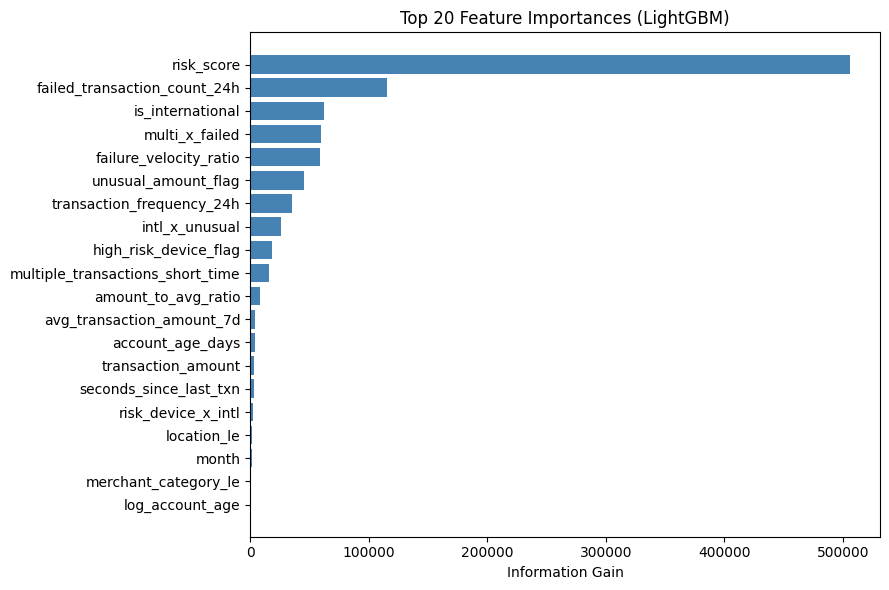

In [15]:
gain_imp = lgb_model.booster_.feature_importance(importance_type='gain')

feat_imp = pd.DataFrame({
    'Feature': X_train_le.columns,
    'Gain':    gain_imp
}).sort_values('Gain', ascending=False).head(20)

print('Top 20 features by information gain:')
print(feat_imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp['Feature'][::-1], feat_imp['Gain'][::-1], color='steelblue')
ax.set_xlabel('Information Gain')
ax.set_title('Top 20 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

## Cell 13 — Generate submission CSV

In [16]:
X_full_le = pd.concat([X_train_le, X_val_le, X_test_le]).reset_index(drop=True)
X_full_ohe = pd.concat([train_ohe, val_ohe, test_ohe]).reset_index(drop=True)
y_full = np.concatenate([y_train, y_val, y_test])

print(f"{X_full_le.shape}")

best_lgb_iters = lgb_model.best_iteration_ if hasattr(lgb_model, 'best_iteration_') else 500
lgb_model_full = lgb.LGBMClassifier(
    n_estimators=best_lgb_iters, learning_rate=0.02, max_depth=6, num_leaves=31,
    min_child_samples=50, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=0.1, random_state=SEED, n_jobs=-1, verbose=-1,
)
lgb_model_full.fit(X_full_le, y_full, categorical_feature=LE_COLS)

best_xgb_iters = xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else 500
xgb_model_full = xgb.XGBClassifier(
    n_estimators=best_xgb_iters, learning_rate=0.02, max_depth=6, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, eval_metric='logloss',
    random_state=SEED, n_jobs=-1, verbosity=0,
)
xgb_model_full.fit(X_full_ohe, y_full)

try:
    best_cb_iters = cb_model.get_best_iteration()
except:
    best_cb_iters = 1000
if best_cb_iters <= 0:
    best_cb_iters = 500

cb_model_full = CatBoostClassifier(
    iterations=best_cb_iters, learning_rate=0.02, depth=6, l2_leaf_reg=3,
    subsample=0.8, random_seed=SEED, verbose=0, cat_features=LE_COLS,
)
cb_model_full.fit(X_full_le, y_full)

rf_model_full = RandomForestClassifier(
    n_estimators=400, max_depth=14, min_samples_split=10, min_samples_leaf=5,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf_model_full.fit(X_full_ohe, y_full)

def preprocess_submission(raw_df, impute_stats, le_dict, train_ohe_cols,
                           train_ref_df, ALL_FEATURES_LE, BASE_FEATURES,
                           CATEGORICAL_COLS, LE_COLS, NUMERIC_COLS, BOOL_COLS):
    d = raw_df.copy()
    original_index = d.index
    d.index = [f"test_idx_{i}" for i in range(len(d))]

    LOCAL_BOOL_MAP = {'true':1,'false':0,'yes':1,'no':0,'y':1,'n':0,'1':1,'0':0}
    for col in BOOL_COLS:
        d[col] = d[col].astype(str).str.strip().str.lower().map(LOCAL_BOOL_MAP)
        d[col] = d[col].fillna(impute_stats[col]).astype(int)

    for col in NUMERIC_COLS:
        d[col] = pd.to_numeric(d[col], errors='coerce')
        d[col] = d[col].where(d[col] >= 0).fillna(impute_stats[col])

    d['payment_method'] = d['payment_method'].apply(clean_payment).fillna(impute_stats['payment_method'])
    d['device_type'] = d['device_type'].apply(clean_device).fillna(impute_stats['device_type'])
    d['merchant_category'] = d['merchant_category'].apply(clean_merchant).fillna(impute_stats['merchant_category'])
    d['location'] = d['location'].astype(str).str.strip().str.lower().map(LOCATION_MAP).fillna('Other')
    d['transaction_timestamp'] = pd.to_datetime(d['transaction_timestamp'], errors='coerce')
    d.loc[:, 'month'] = d['transaction_timestamp'].dt.month
    d.loc[:, 'day_of_week'] = d['transaction_timestamp'].dt.dayofweek

    d = add_features(d, train_ref=train_ref_df)

    for col in CATEGORICAL_COLS:
        le = le_dict[col]
        d[col+'_le'] = d[col].astype(str).map(
            lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
        )

    X_le  = d[ALL_FEATURES_LE]
    combined_cols = list(dict.fromkeys(BASE_FEATURES + CATEGORICAL_COLS))
    X_ohe_sub = d[combined_cols].loc[:, ~d[combined_cols].columns.duplicated()]
    X_ohe = pd.get_dummies(X_ohe_sub, columns=CATEGORICAL_COLS, drop_first=False, dtype=np.uint8).reindex(columns=train_ohe_cols, fill_value=0)
    X_le.index = original_index
    X_ohe.index = original_index
    sub_id = d.get('id', d.get('transaction_id', pd.RangeIndex(len(d))))
    sub_id.index = original_index

    return X_le, X_ohe, sub_id

full_ref = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
test_raw = pd.read_excel(TEST_PATH)
print(test_raw.shape)

X_sub_le, X_sub_ohe, sub_ids = preprocess_submission(
    test_raw, impute_stats, le_dict, train_ohe.columns,
    full_ref, ALL_FEATURES_LE, BASE_FEATURES,
    CATEGORICAL_COLS, LE_COLS, NUMERIC_COLS, BOOL_COLS
)

sub_probs = (
    weights[0] * lgb_model_full.predict_proba(X_sub_le)[:, 1] +
    weights[1] * xgb_model_full.predict_proba(X_sub_ohe)[:, 1] +
    weights[2] * cb_model_full.predict_proba(X_sub_le)[:, 1] +
    weights[3] * rf_model_full.predict_proba(X_sub_ohe)[:, 1]
)


FRAUD_THRESHOLD = 0.85
LEGIT_THRESHOLD = 0.05

high_conf_fraud = sub_probs >= FRAUD_THRESHOLD
high_conf_legit = sub_probs <= LEGIT_THRESHOLD
confident_mask = high_conf_fraud | high_conf_legit

print(f"Total pseudo-labeled data injected: {confident_mask.sum()} rows")

pseudo_X = X_sub_le[confident_mask].copy()
pseudo_y = (sub_probs[confident_mask] >= FRAUD_THRESHOLD).astype(int)

weights_train = np.ones(len(y_full))
weights_pseudo = np.full(len(pseudo_y), 0.4)

X_student = pd.concat([X_full_le, pseudo_X]).reset_index(drop=True)
y_student = np.concatenate([y_full, pseudo_y])
weights_student = np.concatenate([weights_train, weights_pseudo])

student_model = lgb.LGBMClassifier(
    n_estimators=best_lgb_iters + 200,
    learning_rate=0.02, max_depth=6, num_leaves=31,
    min_child_samples=50, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=0.1, random_state=SEED, n_jobs=-1, verbose=-1,
)

student_model.fit(
    X_student, y_student,
    sample_weight=weights_student,
    categorical_feature=LE_COLS
)


final_probs = student_model.predict_proba(X_sub_le)[:, 1]
final_labels = (final_probs >= ens_thresh).astype(int)

submission = pd.DataFrame({'id': sub_ids.values, 'label': final_labels})
submission.to_csv('submission.csv', index=False)

print(submission['label'].value_counts())

(80000, 23)
(20000, 17)
Total pseudo-labeled data injected: 10899 rows
label
1    13335
0     6665
Name: count, dtype: int64
